# Import Required Libraries and Create Clean Datasets

## Import Required Libraries

In [225]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib
import urllib.request
from bs4 import BeautifulSoup
import sqlite3
import sys
!{sys.executable} -m pip install "kagglehub[pandas-datasets]"
import kagglehub
# print("kagglehub works!")
from kagglehub import KaggleDatasetAdapter
import statsmodels.api as sm

## Webscrape the Hosts for Each Year

### Fetch and Locate Hosts Data

In [226]:
# Fetch HTML from Wikipedia page
hosts_url = "https://en.wikipedia.org/wiki/FIFA_World_Cup"

# Create request with custom User Agent to avoid having the request blocked
req = urllib.request.Request(hosts_url, headers={"User-Agent" : "Magic Browser"})

# Retrieve page content
con = urllib.request.urlopen(req)

# Parse the HTML using BeautifulSoup
soup = BeautifulSoup(con.read(), "html.parser")

# Find all tables with the class "wikitable"
wiki_tables = soup.find_all("table", class_=lambda x: x and "wikitable" in x)

# Print number of tables found (commented out after observing)
# print(len(wiki_tables))

# Find table with host countries and year
host_table = None
for table in wiki_tables:
    table_header = table.find_all("th") # Get all header cells
    table_header_txt = " ".join([h.text.strip().lower()
                                 for h in table_header]) # Make a list of lowercase header cells so key words can be searched for
    # Print all header strings so we can choose the most relevant table (commented out after observing)
    # print(table_header_txt)
    if "year" in table_header_txt and "host" in table_header_txt:
        host_table = table # Select the table that has "year" and "host" as headers
        break

# Print to confirm we have the right wikitable (commented out after observing)        
# print(host_table)


### Extract Hosts Data to a DataFrame and Export Raw Data to CSV

In [227]:
# Get every row from the table
rows = host_table.find_all("tr")

data = []

# Skip the first two rows (column names) and extract the rest
for row in rows[2:]:
    cols = [c.text.strip() for c 
            in row.find_all(["td", "th"])] # Extract <td> and <th> without spaces
    data.append(cols)

# Convert to DataFrame
host_df = pd.DataFrame(data, columns = ["Edition", "Year", "Host", "First Place", "Score", 
                                   "Runner-up", "Third Place", "Score2", "Fourth Place", "Nr. of Teams"])

# Print out to check DataFrame (commented out after observing)
# print(host_df)

# Save raw DataFrame as a CSV file
host_df.to_csv("hosts_and_years_raw.csv")


## Cleaning Hosts Data

### Check Data Type for Each Column

In [228]:
# Check data type for each column  (commented out after observing)
# host_df.info()

### Check for Missing Data in the Dataset

In [229]:
# Check for missing data in the dataset  (commented out after observing)
data_missing = host_df.isnull()
# data_missing

In [230]:
# Find missing data count per column (commented out after observing)
# host_df.isnull().sum()

### Drop Rows with Missing Data

##### In 1942 and 1946 no World Cup took place due to WWII
##### The 2026, 2030 and 2034 World Cups haven't taken place yet
##### There is no data for these rows so they should be dropped

#### Clean Missing Score Columns Using SQL

In [231]:
# Create a copy of the original DataFrame to prevent changing raw data
host_df1 = host_df.copy()

# Set up in-memory SQL database to allow SQL cleaning
conn = sqlite3.connect(":memory:")

# Load DataFrame into SQLite as a table
host_df1.to_sql("host_df1", conn, if_exists = "replace", index=False)

# Replace "None", "NaN" and NULL values with an empty string
host_df1 = conn.execute("""
    UPDATE host_df1
    SET Score = ""
    WHERE Score IS NULL OR Score = 'None' OR Score = 'NaN'
""")
conn.commit()

# Print the Score and Year column to check this worked
score_updated = pd.read_sql("""
    SELECT Year, Score
    FROM host_df1
""", conn)

# Print to check this worked (commented out after observing)
# print(score_updated.to_string(index = False))


#### Check we are Dropping the Correct Rows Using SQL

In [232]:
# Check we are dropping the correct rows
check_empty = pd.read_sql("""
    SELECT *
    FROM host_df1
    WHERE Score = ""
""", conn)

# Print to check (commented out after observing)
# print(check_empty.to_string(index = False))

#### Delete the Rows Using SQL

In [233]:
# Dropping the missing data
host_df1 = conn.execute("""
    DELETE FROM host_df1
    WHERE Score = ""
""")
conn.commit()

# Check this worked
rows_not_deleted = pd.read_sql("""
    SELECT *
    FROM host_df1
""", conn)

# Print to check (commented out after observing)
# print(rows_not_deleted.to_string(index = False))

#### Extract Relevant Columns Only Using SQL

In [234]:
# Extract "Year" and "Host" from the hosts_table
host_df1 = pd.read_sql("""
    SELECT Year, Host
    FROM host_df1
""", conn)

# Print the filtered DataFrame to check this worked (commented out after observing)
# print(host_df1.to_string(index=False))

## Download Elo Ratings Dataset into Pandas

##### Please refer to the README file regarding this code
##### The only complete source of Elo Ratings is a JavaScript webpage so I was not able to webscrape as I am not familiar enough with Selenium
##### Instead, this Dataset is downloaded from Kagglehub into Pandas

### Download and Locally Save the Elo Dataset

In [235]:
# Specify the file within the kagglehub dataset
target_file_path = "eloratings.csv"

# Download the specified dataset directly into a Pandas DataFrame
elo_ranking_raw = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "saifalnimri/international-football-elo-ratings",
  target_file_path,
)

# Print to check this has worked properly (commented out after observing)
# print(elo_ranking_raw)

# Save as CSV file
elo_ranking_raw.to_csv("elo_ranking_raw.csv")

/var/folders/kd/p53w9pwd7rv29w5h_tss9l580000gn/T/ipykernel_22018/2582643254.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  elo_ranking_raw = kagglehub.load_dataset(


## Cleaning Elo Data

### Check Data Type for Each Column

In [236]:
# Check data type for each column  (commented out after observing)
# elo_ranking_raw.info()

### Check for Missing Data in the Dataset

In [237]:
# Check for missing data in the dataset  (commented out after observing)
data_missing = elo_ranking_raw.isnull()
# data_missing

In [238]:
# Find missing data count per column (commented out after observing)
# elo_ranking_raw.isnull().sum()

### Drop rows where rating is missing using SQL

##### Please refer to the README file for the reasoning of this

#### Clean missing rating column using SQL

In [239]:
# Create a copy of the original DataFrame to prevent changing raw data
elo_ranking1 = elo_ranking_raw.copy()

# Set up in-memory SQL database to allow SQL cleaning
conn = sqlite3.connect(":memory:")

# Load DataFrame into SQLite as a table
elo_ranking1.to_sql("elo_ranking1", conn, if_exists = "replace", index=False)

# Replace "None", "NaN" and NULL values with an empty string
elo_ranking1 = conn.execute("""
    UPDATE elo_ranking1
    SET rating = ""
    WHERE rating IS NULL OR rating = 'None' OR rating = 'NaN'
""")
conn.commit()

# Print the rating, date and team columns to check this worked
rating_updated = pd.read_sql("""
    SELECT rating, date, team
    FROM elo_ranking1
""", conn)

# Print to check this worked (commented out after observing)
# print(rating_updated.to_string(index = False))


#### Check we are Dropping the Correct Rows Using SQL

In [240]:
# Check we are dropping the correct rows
check_empty = pd.read_sql("""
    SELECT *
    FROM elo_ranking1
    WHERE rating = ""
""", conn)

# Print to check (commented out after observing)
#print(check_empty.to_string(index = False))

# Note: all empty ratings are Moldova


#### Delete the Rows Using SQL

In [241]:
# Dropping the missing data
elo_ranking1 = conn.execute("""
    DELETE FROM elo_ranking1
    WHERE rating = ""
""")
conn.commit()

# Check this worked
rows_not_deleted = pd.read_sql("""
    SELECT *
    FROM elo_ranking1
""", conn)

# Print to check (commented out after observing)
# print(rows_not_deleted.to_string(index = False))

#### Check Rows were Deleted Properly

In [242]:
# Convert SQLite elo_ranking1 to pandas DataFrame
elo_ranking1 = pd.read_sql("""
    SELECT * 
    FROM elo_ranking1
""", conn)

# Return how many null in each column (commented out after observing)
# elo_ranking1.isnull().sum()

### Clean date column to be year only in elo_ranking

In [243]:
# Make copy of table to avoid changing raw data
elo_ranking2 = elo_ranking1.copy()

# Clean to year only (from mixed formatting)
elo_ranking2["date"] = pd.to_datetime(
    elo_ranking2["date"], format = "mixed"
).dt.year

# Check this worked for both date formats (commented out after observing)
# print(elo_ranking2)

### Check for duplicate years in each country for elo_ranking

#### Check how many duplicates are in the DataFrame

In [244]:
# Check how many duplicates are in the DataFrame
duplicates_count = elo_ranking2.duplicated(subset = ["date", "team"]).sum()

# Print to check (commented out after observing)
# print(duplicates_count)

### Clean to get rid of duplicates in elo_ranking

#### Create an average for the ratings column where entries have the same year and team

In [245]:
# Group together entries where date (year) and team are the same, and make the rating the average of these previous entries
elo_ranking3 = elo_ranking2.groupby(["date", "team"], as_index = False)["rating"].mean()

# Print to check (commented out after observing)
# print(elo_ranking3)

#### Check this worked by re-checking for duplicates

In [246]:
# Check how many duplicates are in the DataFrame
duplicates_count = elo_ranking3.duplicated(subset = ["date", "team"]).sum()

# Print to check (commented out after observing)
# print(duplicates_count)
# elo_ranking3

## Webscrape the Names of All Participant Countries

### Fetch and Locate Hosts Data

In [247]:
# Fetch HTML from Wikipedia page
participants_url = "https://en.wikipedia.org/wiki/National_team_appearances_in_the_FIFA_World_Cup"

# Create request with custom User Agent to avoid having the request blocked
req = urllib.request.Request(participants_url, headers={'User-Agent' : "Magic Browser"}) 

# Retrieve page content
con = urllib.request.urlopen(req)

# Parse the HTML using BeautifulSoup
soup = BeautifulSoup(con.read(), "html.parser")

# Find all tables with the class "wikitable"
wiki_table_participants = soup.find_all("table", class_=lambda x: x and "wikitable" in x)

# Print number of tables found (commented out after observing)
#print(len(wiki_table_participants))

# Find table with host countries and year
participants_table = None
for table in wiki_table_participants:
    table_header = table.find_all("th") # Get all header cells
    table_header_txt = " ".join([h.text.strip().lower()
                                 for h in table_header]) # Make a list of lowercase header cells so key words can be searched for
    # Print all header strings so we can choose the most relevant table (commented out after observing)
    # print(table_header_txt)
    if "team" in table_header_txt and "appearances" in table_header_txt:
        participants_table = table # Select the table that has "team" and "appearances" as headers
        break

# Print to confirm we have the right wikitable (commented out after observing)        
# print(participants_table)

### Extract Hosts Data to a DataFrame and Export Raw Data to CSV

In [248]:
# Get every row from the table
rows = participants_table.find_all('tr')

data = []

# Skip the first row (column names) and extract the rest
for row in rows[1:]:
    cols = [c.text.strip() for c 
            in row.find_all(['td', 'th'])] # Extract <td> and <th> without spaces
    data.append(cols)

# Convert to DataFrame
participants = pd.DataFrame(data, columns = ["Team", "Appearances", "Record Streak", "Active Streak", "Debut", 
                                   "Most Recent Qualification", "Best Result"])

# Print out to check DataFrame (commented out after observing)
# print(participants)

# Save raw DataFrame as a CSV file
participants.to_csv("participants_raw.csv")


## Cleaning Participant Country DataFrame

### Delete the countries that have not yet debuted (debut in 2026)

In [249]:
# Create a copy of the original DataFrame to prevent changing raw data
participants1 = participants.copy()

# Set up in-memory SQL database to allow SQL cleaning
conn = sqlite3.connect(":memory:")

# Load DataFrame into SQLite as a table
participants1.to_sql("participants1", conn, if_exists="replace", index=False)

# Dropping the missing data
participants1 = conn.execute("""
    DELETE FROM participants1
    WHERE Debut = 2026
""")
conn.commit()

# Check this worked
rows_deleted = pd.read_sql("""
    SELECT *
    FROM participants1
""", conn)

# Print to check (commented out after observing)
# print(rows_deleted.to_string(index=False))


## Webscrape Stats Per Country Per Year

In [250]:
# Extract World Cup  years from Hosts DataFrame
years = host_df1["Year"].tolist()

# Check this worked (commented out after observing)
# print(years)

""" Remove 1978, 1990 and 2002 from the 'years' variable since they do not display the same result when ran 
since they have different column names """
years.remove("1978")
years.remove("1990")
years.remove("2002")

# Check this worked (commented out after observing)
# print(years)

all_rows = []

# Webscrape final rankings by looping through each World Cup year's wikipedia page
for year in years:

    # Fetch HTML from each year's Wikipedia page
    points_url = f"https://en.wikipedia.org/wiki/{year}_FIFA_World_Cup"

    # Print to check the URLs work (commented out after observing)
    # print("URL:",points_url)

    # Create request with custom User Agent to avoid having the request blocked
    req = urllib.request.Request(points_url, headers={'User-Agent' : "Magic Browser"})

    # Retrieve page content
    con = urllib.request.urlopen(req)

    # Parse the HTML using BeautifulSoup
    soup = BeautifulSoup(con.read(), "html.parser")

    # Find all tables with the class "wikitable" on each page individually
    wiki_table_points = soup.find_all("table", class_="wikitable")

    # Identify the "final ranking" table on each page individually
    points_table = None
    for table in wiki_table_points:

        if points_table is not None:
            break
        header = table.find("tr")
        if header:
            first_th = header.find("th")

            # Identify the "final ranking" table by detecting < abbr > title = "final ranking" 
            if first_th:
                abbr = first_th.find("abbr")
                if abbr and "final ranking" == abbr.get("title", "").lower():
                    points_table = table
     
            if points_table is None:
            # Extract rows from the table

                """ If this does not return a table, identify the "final ranking" table based on length 
                (longer than knockout round tables which are all less than 8 historically) and header text """
                if points_table is None and len(table.find_all("tr")) > 8:
                    last_th = header.find_all("th")[-1]
                    if last_th:
                        text = last_th.text.strip()
                    
                    # Print header text to check what is happening (commented out after observing)
                        # print ("TEXT:", text)

                    # If header equals "Result", treat this as the "final ranking" table
                        if text and "Result" == text:
                            points_table = table

    if points_table is not None:
        # Extract rows from the table 
        rows = points_table.find_all("tr")
    
        for row in rows[1:]:  # Skip header row
            cols = row.find_all(["td", "th"]) # Some years have 13 columns - drop column 13
            
            # Print number of columns to check what is happening (commented out after observing)
            # print("COLLEN: ", len(cols))

            # Clean text from each cell
            cols = [col.get_text(strip=True) for col in cols]
    
            if cols:
                all_rows.append([year] + cols[:11])
    
        # Create DataFrame
        total_points_table_raw = pd.DataFrame(all_rows, columns = ["Year", "Ranking", "Team", "Group", "Matches Played", "Matches Won", 
                                           "Matches Drawn", "Matches Lost", "Goals For", "Goals Against",
                                           "Goal Difference", "Points"])
    
        #print(total_points_table)

    # else:
        # print(f"TABLE NOT FOUND{year}")  # Returns if any years haven't worked so code can be edited (commented out after observing)                      

# Print to check this has worked (commented out after observing)
# print(total_points_table_raw.to_string(index=False))

# Save raw DataFrame as a CSV file
total_points_table_raw.to_csv("total_points_table_raw.csv")


In [251]:
# Extract World Cup  years from Hosts DataFrame
years = ["1978", "1990", "2002"]

# Check this worked (commented out after observing)
# print(years)

all_rows = []

# Webscrape final rankings by looping through each World Cup year's wikipedia page
for year in years:

    # Fetch HTML from each year's Wikipedia page
    points_url = f"https://en.wikipedia.org/wiki/{year}_FIFA_World_Cup"

    # Print to check the URLs work (commented out after observing)
    # print("URL:",points_url)

    # Create request with custom User Agent to avoid having the request blocked
    req = urllib.request.Request(points_url, headers={'User-Agent' : "Magic Browser"})

    # Retrieve page content
    con = urllib.request.urlopen(req)

    # Parse the HTML using BeautifulSoup
    soup = BeautifulSoup(con.read(), "html.parser")

    # Find all tables with the class "wikitable" on each page individually
    wiki_table_points = soup.find_all("table", class_="wikitable")

    # Identify the "final ranking" table on each page individually
    points_table = None
    for table in wiki_table_points:

        if points_table is not None:
            break
        header = table.find("tr")
        if header:
            first_th = header.find("th")

            # Identify the "final ranking" table by detecting < abbr > title = "final ranking" 
            if first_th:
                abbr = first_th.find("abbr")
                if abbr and "final ranking" == abbr.get("title", "").lower():
                    points_table = table
     
            if points_table is None:
            # Extract rows from the table

                """ If this does not return a table, identify the "final ranking" table based on length 
                (longer than knockout round tables which are all less than 8 historically) and header text """
                if points_table is None and len(table.find_all("tr")) > 8:
                    last_th = header.find_all("th")[-1]
                    if last_th:
                        text = last_th.text.strip()
                    
                    # Print header text to check what is happening (commented out after observing)
                        # print ("TEXT:", text)

                    # If header equals "Result", treat this as the "final ranking" table
                        if text and "Result" == text:
                            points_table = table

    if points_table is not None:
        # Extract rows from the table 
        rows = points_table.find_all("tr")
    
        for row in rows[1:]:  # Skip header row
            cols = row.find_all(["td", "th"]) # Some years have 13 columns - drop column 13
            
            # Print number of columns to check what is happening (commented out after observing)
            # print("COLLEN: ", len(cols))

            # Clean text from each cell
            cols = [col.get_text(strip=True) for col in cols]
    
            if cols:
                all_rows.append([year] + cols[:12])
    
        # Create DataFrame
        total_points_table_2_raw = pd.DataFrame(all_rows, columns = ["Year", "Ranking", "Group", "Team", "Matches Played", "Matches Won", 
                                           "Matches Drawn", "Matches Lost", "Goals For", "Goals Against",
                                           "Goal Difference", "Points", "Result"])
    

    # else:
        # print(f"TABLE NOT FOUND{year}")  # Returns if any years haven't worked so code can be edited (commented out after observing)                      

# Print to check this has worked (commented out after observing)
# print(total_points_table_2_raw.to_string(index=False))

# Save raw DataFrame as a CSV file
total_points_table_2_raw.to_csv("total_points_table_2_raw.csv")




## Clean and Merge Stats Per Country Per Year DataFrames

### Delete non-matching or irrelevant columns to be prepared for merge

In [252]:
# Create a copy of the original DataFrame to prevent changing raw data
total_points_table_1_1 = total_points_table_raw.copy()
total_points_table_2_1 = total_points_table_2_raw.copy()

# Delete "Result" and "Group" columns from the 2nd stats per country per year df
total_points_table_2_1 = total_points_table_2_1.drop(columns=["Result"])
total_points_table_2_1 = total_points_table_2_1.drop(columns=["Group"])

# Print to check this worked (commented out after observing)
# print(total_points_table_2_1.to_string(index = False))


In [253]:
# Delete "Group" column from the 1st stats per country per year df
total_points_table_1_1 = total_points_table_1_1.drop(columns=["Group"])

# Print to check this worked (commented out after observing)
#print(total_points_table_1_1.to_string(index = False))

### Concatenate the DataFrames

In [254]:
# Concatenate total_points_table_1_1 and total_points_table_2_1
df_combined = pd.concat([total_points_table_1_1, total_points_table_2_1], ignore_index=True)

# Print to check this worked (commented out after observing)
# print(df_combined.to_string(index = False))

### Get rid of NULL entries (e.g. subheadings that were scraped)

#### Check for NULL entries

In [255]:
# Print DataFrame to find NULL entries (commented out after observing)
# df_combined.isnull()

In [256]:
# Sum for NULL entries in columns (commented out after observing)
# df_combined.isnull().sum()

#### Make all NULL entries have an identifiable characteristic using SQL
##### Please refer to the README for reasoning as to why "Points" was chosen as this identifiable characteristic

In [257]:
# Create a copy of the original DataFrame to prevent changing raw data
df_combined1 = df_combined.copy()

# Set up in-memory SQL database to allow SQL cleaning
conn = sqlite3.connect(":memory:")

# Load DataFrame into SQLite as a table
df_combined1.to_sql("df_combined1", conn, if_exists = "replace", index=False)

# Replace "None", "NaN" and NULL values with an empty string
df_combined1 = conn.execute("""
    UPDATE df_combined1
    SET Points = ""
    WHERE Points IS NULL OR Points = 'None' OR Points = 'NaN'
""")
conn.commit()

# Print the DataFrame to check this worked
points_updated = pd.read_sql("""
    SELECT *
    FROM df_combined1
""", conn)

# Print to check this worked (commented out after observing)
# print(points_updated.to_string(index = False))

# Print to check length of DataFrame (commented out after observing)
# print(len(points_updated))

#### Drop NULL entries

In [258]:
# Dropping the missing data
delete_rows = conn.execute("""
    DELETE FROM df_combined1
    WHERE Points = ""
""")
conn.commit()

# Check this worked
df_combined2 = pd.read_sql("""
    SELECT *
    FROM df_combined1
""", conn)

# Print to check (commented out after observing)
# print(df_combined2.to_string(index = False))

# Print to check length of DataFrame (commented out after observing)
# print(len(df_combined2))

#### Check for NULL entries

In [259]:
# Print DataFrame to find NULL entries (commented out after observing)
# df_combined2.isnull()

In [260]:
# Sum for NULL entries in columns (commented out after observing)
# df_combined2.isnull().sum()

# Graphs and Data Analysis

## Elo Rating against Ranking and Points

### Pre-Merge Checks

#### Create Copies

In [261]:
# Create a copy of the original DataFrames to prevent changing raw data
elo_ranking4 = elo_ranking3.copy()
df_combined3 = df_combined2.copy()

#### Inspect Data

In [262]:
# Check data types of both DataFrames  (commented out after observing)
# elo_ranking4.info()
# df_combined3.info()

In [263]:
# Check DataFrame structures  (commented out after observing)
# elo_ranking4.head()
# df_combined3.head()

#### Standardise keys

In [264]:
# Rename keys in elo_ranking4 to have the same name the equivalent keys in df_combined3
elo_ranking4["Year"] = elo_ranking4["date"]
elo_ranking4["Team"] = elo_ranking4["team"]

In [265]:
# Check Year data types match (commented out after observing)
# print(elo_ranking4["Year"].dtype)
# print(df_combined3["Year"].dtype)

In [266]:
# Convert the data type of the Year column in elo_ranking4 from integer to float
elo_ranking4.Year = elo_ranking4.Year.astype("float")

# Print the data type of Year column in elo_ranking4 to check this worked (commented out after observing)
# print(elo_ranking4["Year"].dtype)


# Convert the data type of the Year column in df_combined3 from object to float
df_combined3.Year = df_combined3.Year.astype("float")

# Print the data type of Year column in df_combined3 to check this worked (commented out after observing)
# print(df_combined3["Year"].dtype)


In [267]:
# Check Team data types match (commented out after observing)
# print(elo_ranking4['Team'].dtype)
# print(df_combined3["Team"].dtype)
# Note: both object - no conversions needed

#### Standardise the Year column values in elo_ranking4

##### Elo rankings for the year before each World Cup must be used.
##### Since Elo rankings are being used a pre World Cup performance metric.
##### Using Elo rankings from the year of the World Cup will capture performance during the World Cup.
##### Please refer to the README regarding this.

In [268]:
# +1 to the elo_ranking4 "Year" column to align with the df_combined3 column
elo_ranking4["Year"] = elo_ranking4["Year"] + 1

### Merging DataFrames

In [269]:
# Left Merge - ensure all df_combined3 data is kept and irrelavnt elo_ranking4 data is discarded
elo_and_performance = pd.merge(df_combined3, elo_ranking4, 
                                on = ["Team", "Year"], 
                                how = "left",
                               validate = "1:1",
                                indicator = True)

# Check this worked (commented out after observing)
# elo_and_performance.head(10)

### Creating Graphs

#### Creating a World Cup Tournament Ranking vs Elo Ranking Scatter Graph

##### Plotting the Scatter Graph and Line of Best Fit

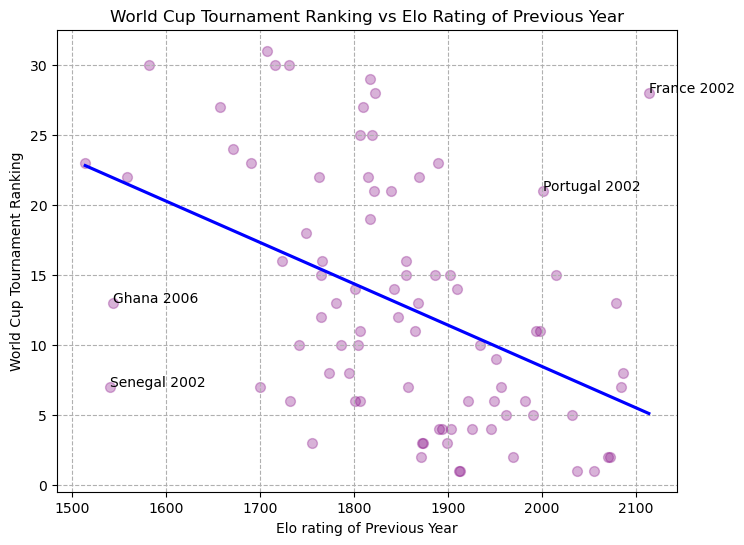

In [270]:
# Close any previously opened figures
plt.close("all")

# Specify the dimensions of the plot
scatter1 = plt.figure(figsize=(8, 6))

# Check the data type of all columns in the dataframe (commented out after observing)
# elo_and_performance.info()

# Convert the data type of the Ranking column from object to float
elo_and_performance.Ranking = elo_and_performance.Ranking.astype("float")

# Create a scatter plot: x = rating (Elo), y = Ranking (within World Cup Tournament)
plt.scatter(elo_and_performance.rating, elo_and_performance.Ranking, s = 50, alpha = 0.3, color = "purple")

# Add the gridlines to the plot
plt.grid(linestyle = "--")

# Add a line of best fit
ax = sns.regplot(data = elo_and_performance, x = "rating",
                 y = "Ranking", scatter = False, color = "blue", ci = None)

# Add the labels and title for the plot
plt.xlabel("Elo rating of Previous Year")
plt.ylabel("World Cup Tournament Ranking")
plt.title("World Cup Tournament Ranking vs Elo Rating of Previous Year")

# Add labels to specific data points (see below, 'Investigating Outliers')
plt.text(1540.0, 7.0, "Senegal 2002")
plt.text(2114.0, 28.0, "France 2002")
plt.text(2001.0, 21.0, "Portugal 2002")
plt.text(1544.0, 13.0, "Ghana 2006")

# Check plot has all necessary features (commented out after observing)
# plt.show()

# Save the plot as a png file
plt.savefig("wc_ranking_vs_elo_rating_scatter.png")


##### Investigating Outliers Using SQL

In [271]:
# Create a copy of the original DataFrame to prevent changing raw data
elo_and_performance_sql = elo_and_performance.copy()

# Drop the "team" column, since it is a duplicate of the "Team" column
elo_and_performance_sql = elo_and_performance_sql.drop("team", axis=1)

# Set up in-memory SQL database to allow SQL cleaning
conn = sqlite3.connect(":memory:")

# Load DataFrame into SQLite as a table
elo_and_performance_sql.to_sql("elo_and_performance_sql", conn, if_exists = "replace", index=False)

# Return the Year and Team of outliers on the graph so they can be added as labels, which may be interesting to the blog reader
# Return the exact Ranking and rating of outliers so labels can be applied to the correct locations
outlier_1 = pd.read_sql("""
    SELECT Year, Team, Ranking, rating
    FROM elo_and_performance_sql
    WHERE Ranking < 10
    AND Ranking > 5
    AND rating > 1500
    AND rating < 1600
""", conn)

outlier_2 = pd.read_sql("""
    SELECT Year, Team, Ranking, rating
    FROM elo_and_performance_sql
    WHERE Ranking < 30
    AND Ranking > 25
    AND rating > 2100
""", conn)

outlier_3 = pd.read_sql("""
    SELECT Year, Team, Ranking, rating
    FROM elo_and_performance_sql
    WHERE Ranking < 25
    AND Ranking > 20
    AND rating > 2000
    AND rating < 2100
""", conn)

outlier_4 = pd.read_sql("""
    SELECT Year, Team, Ranking, rating
    FROM elo_and_performance_sql
    WHERE Ranking < 15
    AND Ranking > 10
    AND rating > 1500
    AND rating < 1600
""", conn)

# Print these results (commented out after observing/copying results)
# print(outlier_1.to_string(index = False))
# print(outlier_2.to_string(index = False))
# print(outlier_3.to_string(index = False))
# print(outlier_4.to_string(index = False))

#### Creating a World Cup Points Per Match vs Elo Ranking Scatter Graph

##### Cleaning Key Names

In [272]:
# Create a copy of the original DataFrame to prevent prevent changing raw data
elo_and_performance1 = elo_and_performance.copy()

# Clean relevant key names to delete whitespace
elo_and_performance1["matches_won"] = elo_and_performance1["Matches Won"]
elo_and_performance1["matches_drawn"] = elo_and_performance1["Matches Drawn"]
elo_and_performance1["matches_lost"] = elo_and_performance1["Matches Lost"]
elo_and_performance1["matches_played"] = elo_and_performance1["Matches Played"]


##### Cleaning Key Data Types

In [273]:
# Convert the data type of the relevant columns from object to float
elo_and_performance1.matches_won = elo_and_performance1.matches_won.astype("float")
elo_and_performance1.matches_drawn = elo_and_performance1.matches_drawn.astype("float")
elo_and_performance1.matches_lost = elo_and_performance1.matches_lost.astype("float")
elo_and_performance1.matches_played = elo_and_performance1.matches_played.astype("float")


##### Clean the Points column

###### Points awarded for winning matches has changed over the course of World Cup History
###### Here, I calculated the points that would be awarded to each team in today's terms, and this is saved in points_modified
###### This is +3 points for a win, +1 for a draw, 0 points for a loss
###### However, the number of teams participating in the World Cup has increased over the years
###### This means raw points cannot be compared over years since you have the potential to play more matches and gain more points in later years
###### Hence, I created a points_per_match column to directly be able to compare performance between years

In [274]:
# Create a points_modified column, that is the 3 * matches won added to matches drawn
elo_and_performance1["points_modified"] = 3*(elo_and_performance1["matches_won"]) + elo_and_performance1["matches_drawn"]

# Create a points_per_match column, that is points_modified divided by matches played
elo_and_performance1["points_per_match"] = elo_and_performance1["points_modified"] / elo_and_performance1["matches_played"]

# Check this worked (commented out after observing)
# elo_and_performance1.head(50)


##### Plotting the Scatter Graph and Line of Best Fit

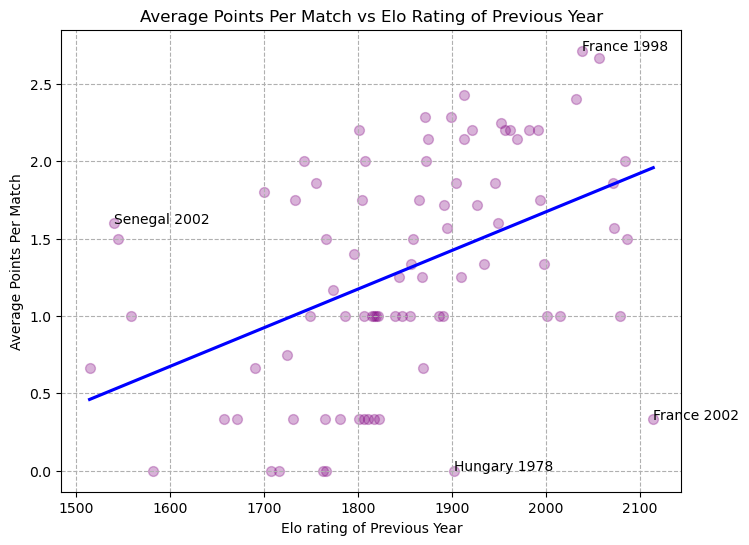

In [275]:
# Close any previously opened figures
plt.close("all")

# Specify the dimensions of the plot
scatter1 = plt.figure(figsize=(8, 6))

# Check the data type of all columns in the dataframe (commented out after observing)
# elo_and_performance1.info()

# Convert the data type of the points_per_match column from object to float
elo_and_performance1.points_per_match = elo_and_performance1.points_per_match.astype("float")

# Create a scatter plot: x = rating (Elo), y = points per match
plt.scatter(elo_and_performance1.rating, elo_and_performance1.points_per_match, s = 50, alpha = 0.3, color = "purple")

# Add the gridlines to the plot
plt.grid(linestyle = "--")

# Add a line of best fit
ax = sns.regplot(data = elo_and_performance1, x = "rating",
                 y = "points_per_match", scatter = False, color = "blue", ci = None)

# Add the labels and title for the plot
plt.xlabel("Elo rating of Previous Year")
plt.ylabel("Average Points Per Match")
plt.title("Average Points Per Match vs Elo Rating of Previous Year")

# Add labels to specific data points (see below, 'Investigating Outliers')
plt.text(2114.0, 0.333333, "France 2002")
plt.text(1902.0, 0.0, "Hungary 1978")
plt.text(2038.0, 2.714286, "France 1998")
plt.text(1540.0, 1.6, "Senegal 2002")

# Check plot has all necessary features (commented out after observing)
# plt.show()

# Save the plot as a png file
plt.savefig("points_per_match_vs_elo_rating_scatter.png")

##### Investigating Outliers Using SQL

In [276]:
# Create a copy of the original DataFrame to prevent changing raw data
elo_and_performance1_sql = elo_and_performance1.copy()

# Drop the "team" column, since it is a duplicate of the "Team" column
elo_and_performance1_sql = elo_and_performance1_sql.drop("team", axis=1)

# Set up in-memory SQL database to allow SQL cleaning
conn = sqlite3.connect(":memory:")

# Load DataFrame into SQLite as a table
elo_and_performance1_sql.to_sql("elo_and_performance1_sql", conn, if_exists = "replace", index=False)

# Return the Year and Team of outliers on the graph so they can be added as labels, which may be interesting to the blog reader
# Return the exact Ranking and rating of outliers so labels can be applied to the correct locations
outlier_1 = pd.read_sql("""
    SELECT Year, Team, points_per_match, rating
    FROM elo_and_performance1_sql
    WHERE points_per_match > 0
    AND points_per_match < 0.5
    AND rating > 2100
""", conn)

outlier_2 = pd.read_sql("""
    SELECT Year, Team, points_per_match, rating
    FROM elo_and_performance1_sql
    WHERE points_per_match > -1
    AND points_per_match < 0.5
    AND rating > 1900
    AND rating < 2000
""", conn)

outlier_3 = pd.read_sql("""
    SELECT Year, Team, points_per_match, rating
    FROM elo_and_performance1_sql
    WHERE points_per_match > 2.5
    AND rating > 2000
    AND rating < 2050
""", conn)

outlier_4 = pd.read_sql("""
    SELECT Year, Team, points_per_match, rating
    FROM elo_and_performance1_sql
    WHERE points_per_match > 1.5
    AND rating > 1500
    AND rating < 1600
""", conn)

# Print these results (commented out after observing/copying results)
# print(outlier_1.to_string(index = False))
# print(outlier_2.to_string(index = False))
# print(outlier_3.to_string(index = False))
# print(outlier_4.to_string(index = False))

### Data Analysis

#### Model whether pre-tournament Elo ratings are statistically significant to World Cup performance

In [277]:
# Select relevant variables: (Elo) rating and (average) points_per_match
# Remove missing values
df_clean = elo_and_performance1[["rating", "points_per_match"]].dropna()

# Define independent variable as (Elo) rating
X = df_clean["rating"]

# Define dependent variable as (average) points_per_match - our World Cup performance metric
y = df_clean["points_per_match"]   

# Add intercept so model not forced through the origin
X = sm.add_constant(X)

# Run OLS regression
elo_points_per_match_model = sm.OLS(y, X).fit()

# Print these results (commented out after observing)
# print(elo_points_per_match_model.summary())


## Host Advantage

### Pre-Merge Checks

#### Create Copies

In [278]:
# Create a copy of the original DataFrames to prevent changing raw data
elo_and_performance2 = elo_and_performance1.copy()
host_df2 = host_df1.copy()


#### Inspect Data

In [279]:
# Check data types of both DataFrames  (commented out after observing)
# elo_and_performance2.info()
# host_df2.info()

In [280]:
# Check DataFrame structures  (commented out after observing)
# print(elo_and_performance2.to_string(index=False))
# host_df2.head()

#### Standardise Keys

In [281]:
# Check Year data types match (commented out after observing)
# print(elo_and_performance2["Year"].dtype)
# print(host_df2["Year"].dtype)

In [282]:
# Convert the data type of the Year column in host_df2 from object to float
host_df2.Year = host_df2.Year.astype("float")

# Print the data type of Year column in host_df2 to check this worked (commented out after observing)
# print(host_df2["Year"].dtype)


### Merging DataFrames

In [283]:
# Left Merge - ensure all elo_and_performance2 data is kept so we have both host and non-host performance data
# Let epah stand for elo_performance_and_hosts for succinctness
epah = pd.merge(elo_and_performance2, host_df2, 
                                on = ["Year"], 
                                how = "left",
                               validate = "m:1",
                                indicator = "merge_2")

# Check this worked (commented out after observing)
# print(epah.to_string(index = False))

### Creating Graphs - Host vs Non-Host Box Plot Comparison

#### Cleaning Column Names & Selecting Host vs Non-host Characteristics

In [284]:
# Create a copy of the original DataFrame to prevent changing raw data
epah1 = epah.copy()

epah1 = epah1.drop(columns=['team'])

# Set up in-memory SQL database to allow SQL cleaning
conn = sqlite3.connect(":memory:")

# Load DataFrame into SQLite as a table
epah1.to_sql("epah1", conn, if_exists = "replace", index=False)

# Print the Score and Year column to check this worked
epah_hosts = pd.read_sql("""
    SELECT *
    FROM epah1
    WHERE "Team" = Host
""", conn)

epah_non_hosts = pd.read_sql("""
    SELECT *
    FROM epah1
    WHERE "Team" != Host
""", conn)

# Print to check this worked (commented out after observing)
# print(epah_hosts.to_string(index = False))
# print(epah_non_hosts.to_string(index = False))

#### Find Average Points per Match for Hosts and Non-hosts

In [285]:
# Calculate apm (Average Points per Match) from each DataFrame
apm_hosts = epah_hosts["points_per_match"].mean()
apm_non_hosts = epah_non_hosts["points_per_match"].mean()

# Print to check this worked (commented out after observing)
# print(apm_hosts)
# print(apm_non_hosts)

#### Plot Histogram

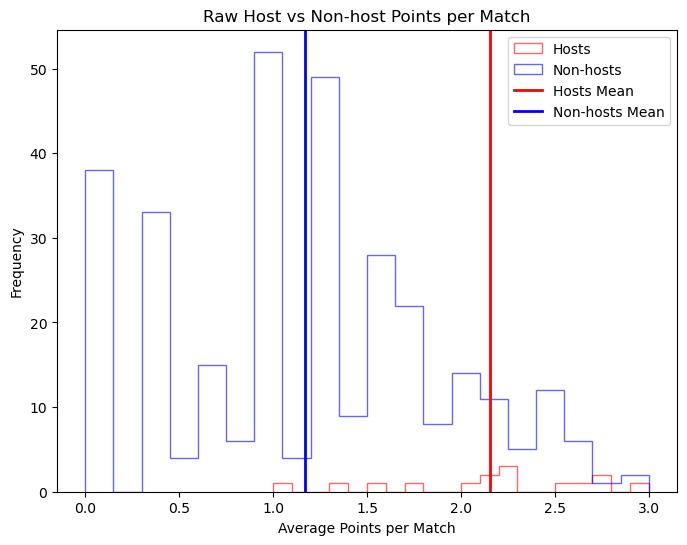

<Figure size 640x480 with 0 Axes>

In [286]:
# Close any previously opened figures
plt.close("all")

# Specify the dimensions of the plot
plt.figure(figsize=(8,6))

# Check the data type of all columns in the dataframes (commented out after observing)
# epah_hosts.info()
# epah_non_hosts.info()

# Create a histogram
plt.hist(epah_hosts.points_per_match, bins = 20, color = "red",
         alpha = 0.6, label = "Hosts", histtype = "step")
plt.hist(epah_non_hosts.points_per_match, bins = 20, color = "blue",
         alpha = 0.6, label = "Non-hosts", histtype = "step")


# Add the labels and title for the plot
plt.xlabel("Average Points per Match")
plt.ylabel("Frequency")
plt.title("Raw Host vs Non-host Points per Match")

# Add Average Points per Match lines
plt.axvline(apm_hosts, color = "red", linewidth = 2, label = "Hosts Mean")
plt.axvline(apm_non_hosts, color = "blue", linewidth = 2, label = "Non-hosts Mean")
plt.legend()

# Check plot has all necessary features (commented out after observing)
plt.show()

# Save the plot as a png file
plt.savefig("raw_host_vs_non_host_points_per_match.png")
